In [7]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("disentanglement_scores.csv")

scores = ['DCI-D', 'DCI-C', 'DCI-I', 'IRS', 'MIG', '3CharM']

model_name_map = {
    ('MNIST', '2 Views'): 'MNIST 2V',
    ('MM-CelebA-HQ', '2 Views - IL'): 'MM-CelebA-HQ 2V-IL',
    ('MM-CelebA-HQ', '3 Views'): 'MM-CelebA-HQ 3V'
}

df['Model'] = df[['Architecture', 'Views']].apply(
    lambda row: model_name_map[(row['Architecture'], row['Views'])],
    axis=1
)

models = ['MNIST 2V', 'MM-CelebA-HQ 2V-IL', 'MM-CelebA-HQ 3V']

score_values = np.array([
    df.loc[df['Model'] == model, scores].mean().values
    for model in models
])

In [9]:
x = np.arange(len(scores))
width = 0.24

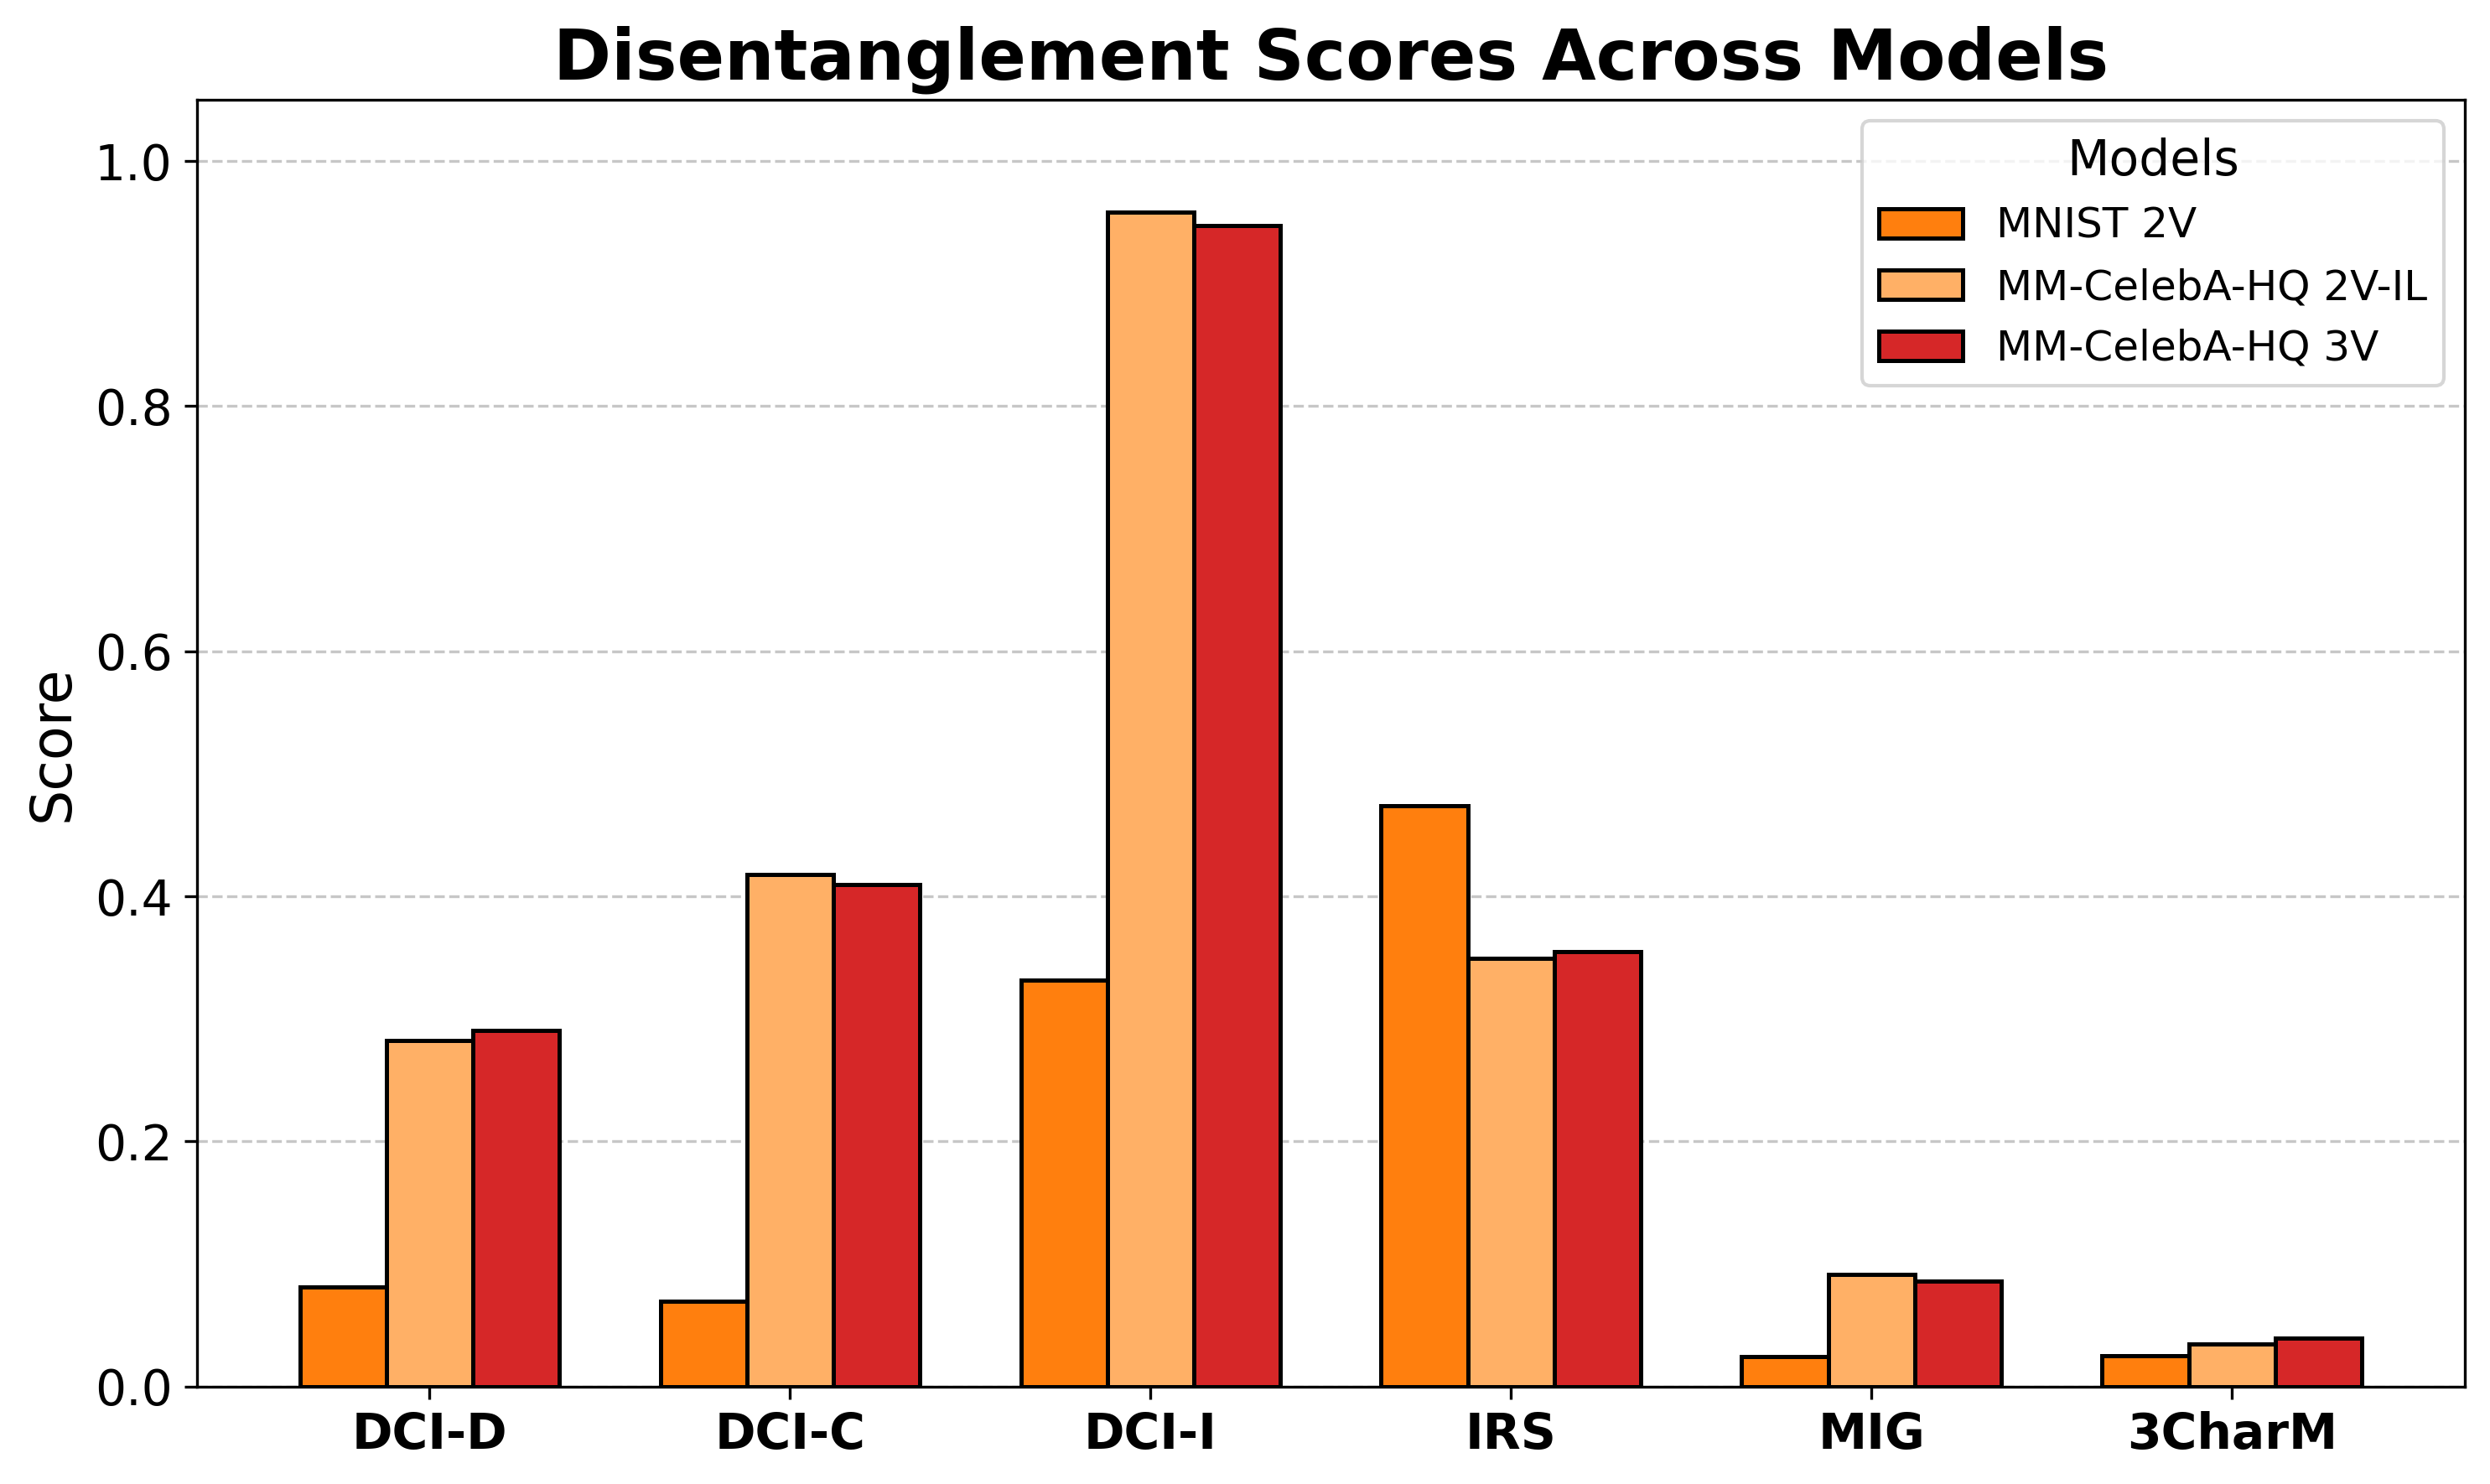

In [10]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

model_color_map = {
    'MNIST 2V': 'tab:orange',
    'MM-CelebA-HQ 2V-IL': '#ffb066',
    'MM-CelebA-HQ 3V': 'tab:red'
}
# hatches = ['', '//', '//']

for i, model in enumerate(models):
    offset = (i - 1) * width

    ax.bar(
        x + offset,
        score_values[i],
        width,
        label=model,
        color=model_color_map.get(model),
        edgecolor='black',
        # hatch=hatches[i],
        linewidth=1.2
    )

ax.set_title('Disentanglement Scores Across Models', fontsize=20, fontweight='bold')
ax.set_ylabel('Score', fontsize=16)

ax.set_xticks(x)
ax.set_xticklabels(scores, fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=14)

ax.set_ylim(0, 1.05)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

ax.legend(fontsize=12, title='Models', title_fontsize=14, loc='upper right')

plt.tight_layout()
plt.savefig('./img/disentanglement_scores.png', dpi=300)
plt.show()

/var/folders/yd/xmg755ln3fscr3pf2_0xpclm0000gn/T/ipykernel_20827/873774064.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


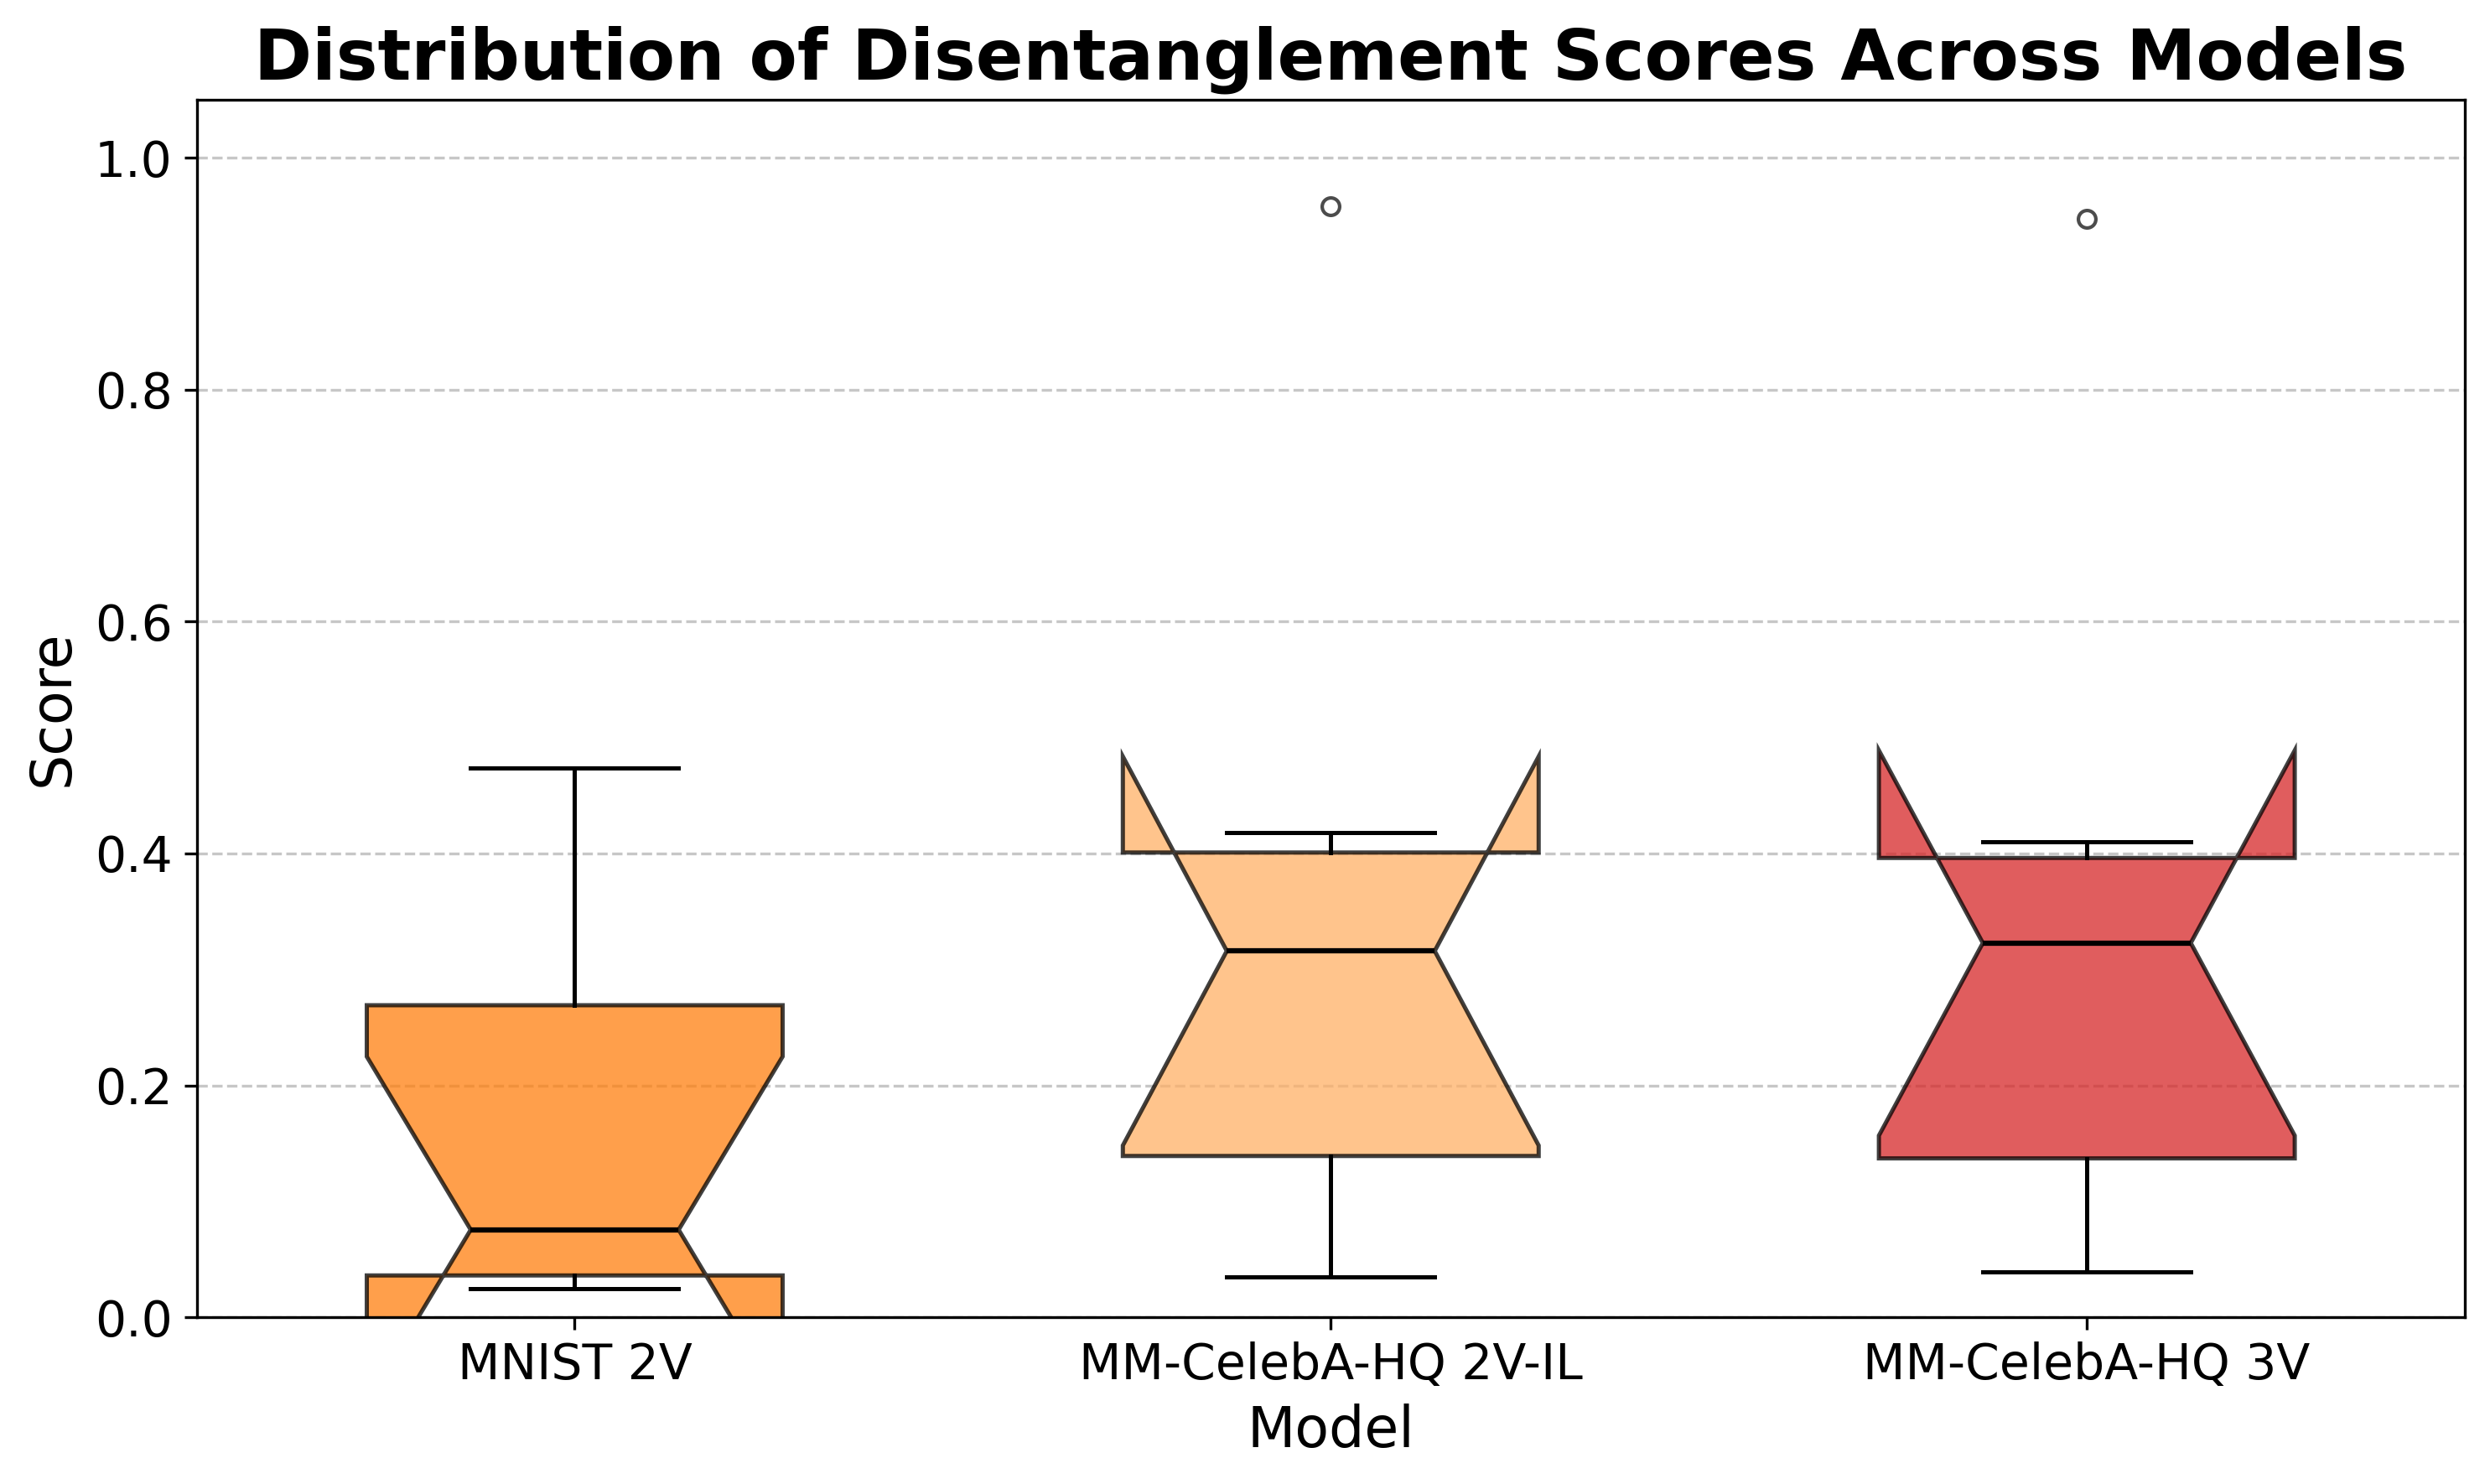

In [11]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

bp = ax.boxplot(
    score_values.T,
    labels=models,
    notch=True,
    patch_artist=True,
    widths=0.55,
    medianprops=dict(color='black', linewidth=1.5),
    boxprops=dict(linewidth=1.2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=5, alpha=0.7)
)

for patch, model in zip(bp['boxes'], models):
    patch.set_facecolor(model_color_map[model])
    patch.set_alpha(0.75)

ax.set_title('Distribution of Disentanglement Scores Across Models', fontsize=20, fontweight='bold')
ax.set_ylabel('Score', fontsize=16)
ax.set_xlabel('Model', fontsize=16)

ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

ax.set_ylim(0, 1.05)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('./img/boxplot_disentanglement_scores.png', dpi=300)
plt.show()

## Statistical tests

In [12]:
alpha = 0.05

normality_results = []
test_results = {}
posthoc_results = {}

for score in scores:
    print(f"\n===== {score} =====")

    groups = [
        df.loc[df["Model"] == model, score].dropna().values
        for model in models
    ]

    # Shapiro-Wilk normality test per model
    is_normal = True

    print("\nNormality test:")
    for model, values in zip(models, groups):
        shapiro_stat, shapiro_p = stats.shapiro(values)

        normality_results.append({
            "Score": score,
            "Model": model,
            "W": shapiro_stat,
            "p-value": shapiro_p,
            "Normal": shapiro_p >= alpha
        })

        print(f"{model}: W = {shapiro_stat}, p = {shapiro_p}")

        if shapiro_p < alpha:
            is_normal = False

    df_score = df[["Model", score]].dropna().rename(columns={score: "Score"})

    # ANOVA + Tukey if all groups are normal
    if is_normal:
        stat, p_value = stats.f_oneway(*groups)

        test_results[score] = {
            "Test": "ANOVA",
            "Statistic": stat,
            "p-value": p_value
        }

        print(f"\nANOVA: F = {stat}, p = {p_value}")

        if p_value < alpha:
            tukey_results = sp.posthoc_tukey(
                df_score,
                val_col="Score",
                group_col="Model"
            )

            posthoc_results[score] = tukey_results

            print("\nTukey post-hoc groups:")
            print(sp.compact_letter_display(tukey_results))
        else:
            print("\nNo significant difference, so no post-hoc test needed.")

    # Kruskal-Wallis + Dunn if at least one group is not normal
    else:
        stat, p_value = stats.kruskal(*groups)

        test_results[score] = {
            "Test": "Kruskal-Wallis",
            "Statistic": stat,
            "p-value": p_value
        }

        print(f"\nKruskal-Wallis: H = {stat}, p = {p_value}")

        if p_value < alpha:
            dunn_results = sp.posthoc_dunn(
                df_score,
                val_col="Score",
                group_col="Model",
                p_adjust="bonferroni"
            )

            posthoc_results[score] = dunn_results

            print("\nDunn post-hoc groups:")
            print(sp.compact_letter_display(dunn_results))
        else:
            print("\nNo significant difference, so no post-hoc test needed.")


===== DCI-D =====

Normality test:
MNIST 2V: W = 0.9206625608715338, p = 0.36251408830287674
MM-CelebA-HQ 2V-IL: W = 0.9351051072833045, p = 0.499936078223046
MM-CelebA-HQ 3V: W = 0.9546294356320353, p = 0.7233307610558689

ANOVA: F = 891.4270680370905, p = 2.214229123909386e-25

Tukey post-hoc groups:
MNIST 2V              a 
MM-CelebA-HQ 2V-IL     b
MM-CelebA-HQ 3V        b
Name: letters, dtype: object

===== DCI-C =====

Normality test:
MNIST 2V: W = 0.9473785875427991, p = 0.637601066242699
MM-CelebA-HQ 2V-IL: W = 0.9049457899938719, p = 0.24804534985980936
MM-CelebA-HQ 3V: W = 0.958294549532472, p = 0.7662644531644403

ANOVA: F = 2191.288273741248, p = 1.3306163452681702e-30

Tukey post-hoc groups:
MNIST 2V              a 
MM-CelebA-HQ 2V-IL     b
MM-CelebA-HQ 3V        b
Name: letters, dtype: object

===== DCI-I =====

Normality test:
MNIST 2V: W = 0.8583064878564903, p = 0.07287630049937953
MM-CelebA-HQ 2V-IL: W = 0.875711213696127, p = 0.11645675823008232
MM-CelebA-HQ 3V: W = 